ở đây sẽ train thử RNN đơn giản bằng Pytorch
dùng data là MNIST ảnh trong MNIST là 28 x 28 nên ta sẽ có kiểu là 
(batch_Size, 28, 28) nghĩa là coi mỗi hàng của ảnh trong MNIST là một từ :v


In [1]:
import torch 
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [ ]:
# dùng pytorch nên ta câu hình thiết bị chạy trên GPU nếu có

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

cpu


In [9]:
# hyperparameters
sequence_length = 28
input_size = 28
hidden_size = 128
num_classes = 10
batch_size = 100
num_epochs = 5
learning_rate = 0.001


In [ ]:
# tải data về
# tải tập train và test về 
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor()) # thằng này ko có dowload vì đã được tải ở trên
# chia thành các batch để sau này huấn luyện (shuffle = True là xóa trộn lên để tránh học vẹt)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# build RNN
class SimpleRNNImage(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()

        self.hidden_size = hidden_size

        self.rnn = nn.RNN(input_size, hidden_size, batch_first= True)

        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        # để mặc định cho cái trạng thái ban đầu 
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(device)

        out, _ = self.rnn(x, h0)

        # out có dạng (batch_size, seq_length, hidden_size)
        """
            Cú pháp out[:, -1, :] chính là con dao cắt lớp Tensor đó:

            Dấu : thứ nhất: Lấy tất cả 100 bức ảnh trong Batch.

            Số -1 ở giữa: Đây là index của Python, nghĩa là lấy bước thời gian cuối cùng (bước số 28). Nó vứt bỏ dữ liệu của 27 bước trước đó vì lúc đó mạng chưa đọc hết ảnh.

            Dấu : thứ ba: Lấy tất cả 128 đặc trưng (Ký ức) tại bước thời gian cuối cùng đó.
        """
        out = self.fc(out[:, -1, :])

        return out

model = SimpleRNNImage(input_size, hidden_size, num_classes).to(device)
# cài đặt hàm chuẩn hóa và Lossfunction
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr= learning_rate)



Bắt đầu huấn luyện...
Epoch [1/5], Step [200/600], Loss: 0.8123
Epoch [1/5], Step [400/600], Loss: 1.0043
Epoch [1/5], Step [600/600], Loss: 0.5424
Epoch [2/5], Step [200/600], Loss: 0.3631
Epoch [2/5], Step [400/600], Loss: 0.4527
Epoch [2/5], Step [600/600], Loss: 0.2984
Epoch [3/5], Step [200/600], Loss: 0.1863
Epoch [3/5], Step [400/600], Loss: 0.2509
Epoch [3/5], Step [600/600], Loss: 0.1567
Epoch [4/5], Step [200/600], Loss: 0.1675
Epoch [4/5], Step [400/600], Loss: 0.2452
Epoch [4/5], Step [600/600], Loss: 0.2150
Epoch [5/5], Step [200/600], Loss: 0.0617
Epoch [5/5], Step [400/600], Loss: 0.1265
Epoch [5/5], Step [600/600], Loss: 0.0855
Hoàn tất huấn luyện!


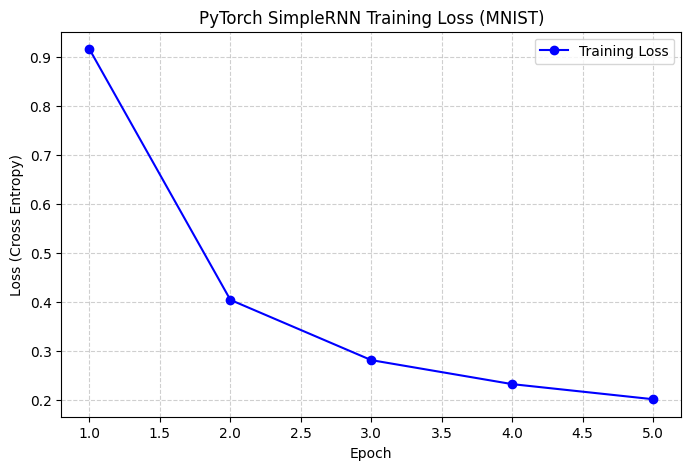

In [ ]:
# Mảng lưu lại lịch sử điểm loss để vẽ biểu đồ
loss_history = []
total_step = len(train_loader)

print("Bắt đầu huấn luyện...")

for epoch in range(num_epochs):
    epoch_loss = 0
    for i, (images, labels) in enumerate(train_loader):
        # cái này chỉ là chuẩn hóa đầu vào vì ban đầu data là 100, 1, 28, 28 thì thành 100, 28, 28
        # -1 sẽ tự chỉnh cái batch_size sao cho đều và phù hợp
        images = images.reshape(-1, sequence_length, input_size)
        labels = labels.to(device)

        # xóa rác đạo hàm
        optimizer.zero_grad()

        # chạy xuôi
        # cái này là yêu cầu của pytorch khi ta không trực tiếp gọi thẳng hàm forward luôn mà ta phải gọi qua cái model không lúc sau chạy BPTT sẽ không được
        outputs = model(images)

        # tính loss
        loss = criterion(outputs, labels)

        # chạy BPTT
        loss.backward()

        # cập nhật trọng số
        optimizer.step()

        epoch_loss += loss.item()
        
        if (i+1) % 200 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_step}], Loss: {loss.item():.4f}')
            
    # Lưu trung bình loss của mỗi epoch
    loss_history.append(epoch_loss / total_step)

print("Hoàn tất huấn luyện!")

# Vẽ biểu đồ Loss giống trong tài liệu
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), loss_history, marker='o', color='b', label='Training Loss')
plt.title('PyTorch SimpleRNN Training Loss (MNIST)')
plt.xlabel('Epoch')
plt.ylabel('Loss (Cross Entropy)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()